In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
notebook_path = Path.cwd()
base_path = notebook_path.parent

raw_path = base_path / "data" / "raw" 
plot_path = base_path / "fig"

In [3]:
toc=pd.read_csv(raw_path / "toc.csv", sep = ";")

In [4]:
# Step 2: Calculate organic matter lost (this is second step)
toc["organic_matter"] = toc["dry_weight"] - toc["ash_weight"]
toc["toc_percent"] = (toc["organic_matter"] / toc["dry_weight"]) * 100 * 0.58

In [5]:
# Group by site to get mean and standard deviation
grouped = toc.groupby('site')['toc_percent'].agg(['mean', 'std']).reset_index()
mean_series_per_site = toc.groupby(['site', 'month', 'sample'])['toc_percent'].agg(['mean', 'std']).reset_index()
mean_series = toc.groupby(['month', 'sample'])['toc_percent'].agg(['mean', 'std']).reset_index()

total_series_per_site = toc.groupby(['site', 'month', 'sample'])['toc_percent'].agg(['sum']).reset_index()
total_series = toc.groupby(['month', 'sample'])['toc_percent'].agg(['sum']).reset_index()

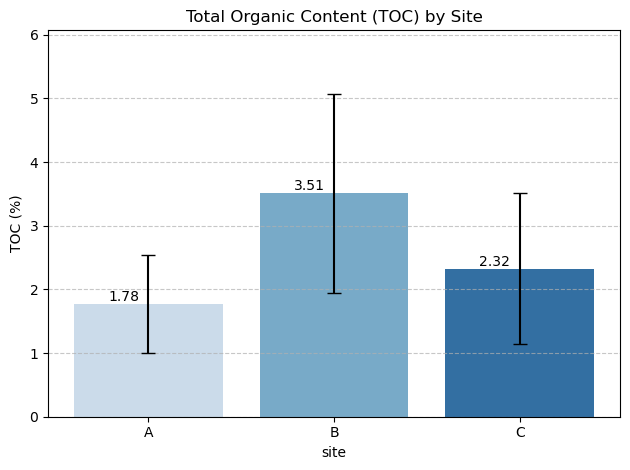

In [6]:
# Step 4: Plot the TOC% per site
fig, ax = plt.subplots(1,1)

bars = sns.barplot(
    data=grouped,
    x='site', y='mean',hue='site',
    palette='Blues',
    ax=ax,
    errorbar=None  # disable built-in CI
)

# Add custom error bars for std
ax.errorbar(
    x=np.arange(len(grouped)),
    y=grouped['mean'],
    yerr=grouped['std'],
    fmt='none', c='black', capsize=5
)

ax.set_ylabel('TOC (%)')
ax.set_title('Total Organic Content (TOC) by Site')
ax.set_ylim(0, max(grouped['mean'] + grouped['std']) + 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels on top of bars
for bar, label in zip(ax.patches, grouped['mean']):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/3, height,
        f"{label:.2f}",
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.savefig(plot_path / "toc.png", dpi=500)
plt.show()